<a href="https://colab.research.google.com/github/samuelwoldegiorgis/DEVOPSFORCICD/blob/master/LDA05_31_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf


data = pd.read_csv("AirPassengers.csv")
data.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [ ]:
data['Month'] = pd.to_datetime(data['Month'])
data.head()

,Month,#Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [ ]:
data = data.set_index('Month')
data.head()

,#Passengers
Month,
1949-01,112
1949-02,118
1949-03,132
1949-04,129
1949-05,121


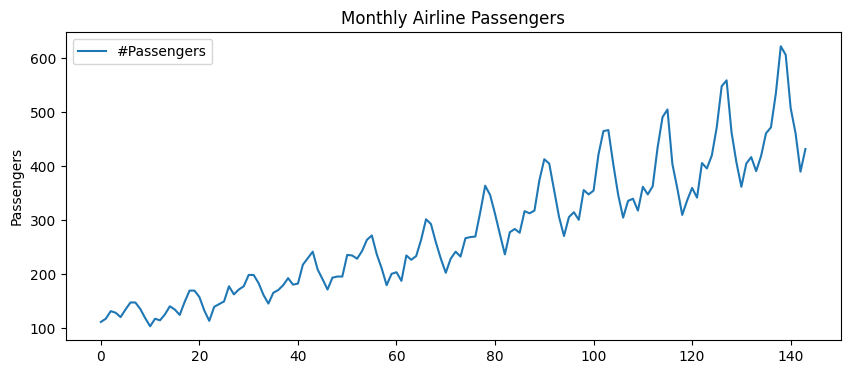

In [ ]:
data.plot(figsize=(10, 4), title='Monthly Airline Passengers')
plt.ylabel('Passengers')
plt.show()

In [ ]:
mean_12 = data['#Passengers'].rolling(window = 12).mean()
std_12 = data['#Passengers'].rolling(window = 12).std()

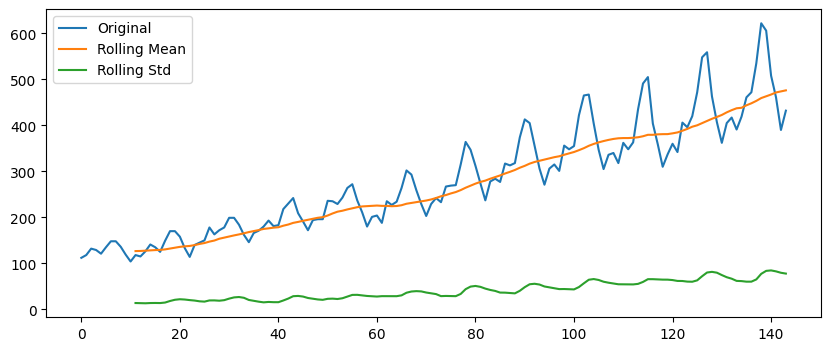

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(data['#Passengers'], label = 'Original')
plt.plot(mean_12, label = 'Rolling Mean')
plt.plot(std_12, label = 'Rolling Std')
plt.legend(loc = 'best')
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(data['#Passengers'])
print('p-value: %f' % result[1])

p-value: 0.991880


In [ ]:
data_diff = data['#Passengers'].diff().dropna()
print(data_diff.head())

1     6.0
2    14.0
3    -3.0
4    -8.0
5    14.0
Name: #Passengers, dtype: float64


In [ ]:
data_log  = np.log(data['#Passengers'])
data_log.head()

,#Passengers
0,4.718499
1,4.770685
2,4.882802
3,4.859812
4,4.795791


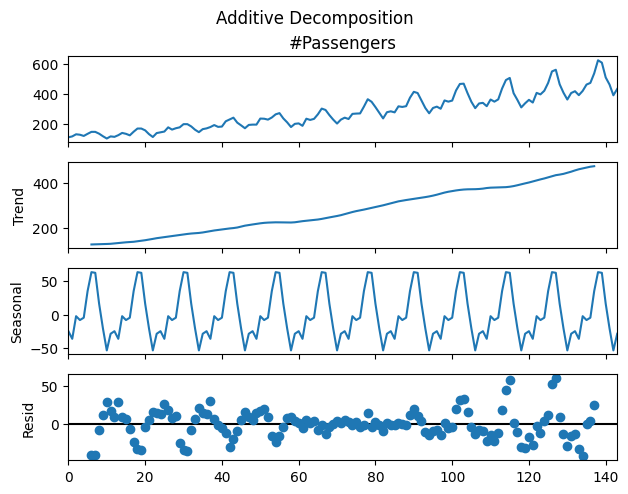

In [ ]:
additive_decomp = seasonal_decompose(data['#Passengers'], model = 'additive', period = 12)
additive_decomp.plot()
plt.suptitle("Additive Decomposition", y= 1.02)
plt.show()

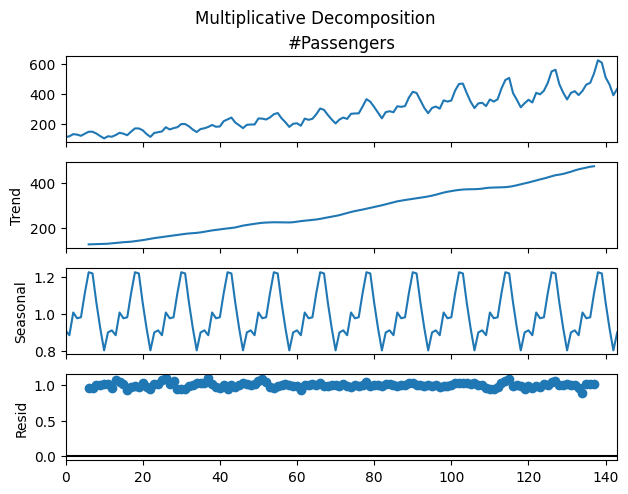

In [ ]:
multiplicative_decomp = seasonal_decompose(data['#Passengers'], model = 'multiplicative', period = 12)
multiplicative_decomp.plot()
plt.suptitle("Multiplicative Decomposition", y= 1.02)
plt.show()

In [ ]:
comp = pd.DataFrame({"additive_seasonal_plus_minus":additive_decomp.seasonal.dropna().head(12).values, "multiplicative_seasonal_factor": multiplicative_decomp.seasonal.dropna().head(12).values}, index = additive_decomp.seasonal.dropna().head(12))


In [ ]:
comp

,additive_seasonal_plus_minus,multiplicative_seasonal_factor
seasonal,,
-24.748737,-24.748737,0.910230
-36.188131,-36.188131,0.883625
-2.241162,-2.241162,1.007366
-8.036616,-8.036616,0.975906
-4.506313,-4.506313,0.981378
35.402778,35.402778,1.112776
63.830808,63.830808,1.226556
62.823232,62.823232,1.219911
16.520202,16.520202,1.060492


<Figure size 1000x400 with 0 Axes>

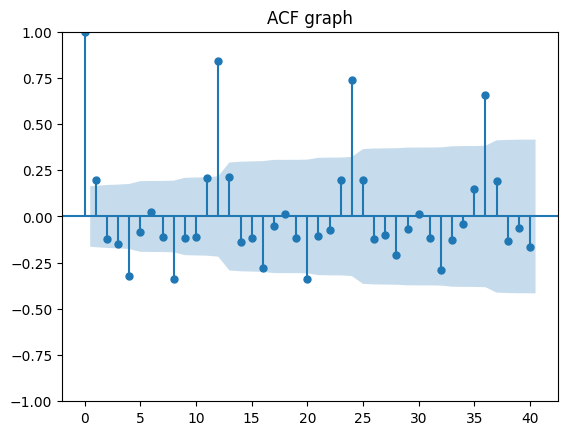

In [ ]:
data['log_passengers'] = np.log(data['#Passengers'])
data['first_diff'] = data['#Passengers'].diff()
data['log_first_diff'] = data['log_passengers'].diff()
data.head()
plt.figure(figsize=(10,4))
plot_acf(data['log_first_diff'].dropna(), lags = 40)
plt.title("ACF graph")
plt.show()

In [ ]:
data.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


<Figure size 1000x400 with 0 Axes>

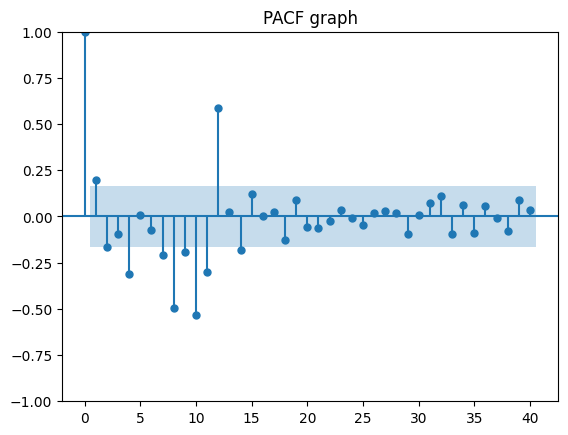

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf

# Ensure 'Month' is datetime and set as index if not already done
if 'Month' in data.columns:
    data['Month'] = pd.to_datetime(data['Month'])
    data = data.set_index('Month')

# Create the necessary columns for PACF plot
data['log_passengers'] = np.log(data['#Passengers'])
data['first_diff'] = data['#Passengers'].diff()
data['log_first_diff'] = data['log_passengers'].diff()

plt.figure(figsize=(10,4))
plot_pacf(data['log_first_diff'].dropna(), lags = 40)
plt.title("PACF graph")
plt.show()